# Day 4 – Tutorial MFM

In Day 3, we introduced the Purkinje cell (PC) Z+ model and derived its numerical transfer function (TF) template.

Today, we will compare different single-cell PC models and investigate how the numerical TF template changes under the **Z−** and **SCA6-like dysfunction** conditions, focusing on the corresponding **electrophysiological modifications**.


# 0. Enviroment setup

In [20]:
!pip install -q condacolab
import condacolab
condacolab.install()

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip", line 10, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/site-packages/pip/_internal/cli/main.py", line 47, in main
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.13/site-packages/pip/_internal/cli/autocompletion.py", line 12, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.13/site-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._vendor.rich.markup import escape
  File "/usr/local/lib/python3.13/site-packages/pip/_vendor/rich/__init__.py", line 17, in <module>
    _IMPORT_CWD = os.path.abspath(os.getcwd())
                                  ~~~~~~~~~^^
OSError: [Errno 107] Transport endpoint is not connected

📢 Announcement 📢
con

In [21]:
!mamba install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
critical libmamba filesystem error: cannot get current path: Transport endpoint is not connected


In [78]:
from google.colab import drive, output
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [80]:
import os
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day4")

In [24]:
!pip install -r ../Colab/requirements.txt

  Using cached arborize-7.6.0-py3-none-any.whl
  Using cached nrn_patch-7.6.0-py3-none-any.whl
  Using cached nmodl_glia-7.6.0-py3-none-any.whl
  Using cached bsb_core-7.6.0-py3-none-any.whl
  Using cached bsb_hdf5-7.6.0-py3-none-any.whl
  Using cached bsb_json-7.6.0-py3-none-any.whl
  Using cached bsb_yaml-7.6.0-py3-none-any.whl
  Using cached bsb_otel-7.6.0-py3-none-any.whl
  Using cached bsb_nest-7.6.0-py3-none-any.whl
  Using cached bsb_native-7.4.0-cp310-abi3-linux_x86_64.whl
  Using cached bsb-7.6.0-py3-none-any.whl
  Cloning https://github.com/dbbs-lab/cerebellar-models.git (to revision feature/auto_mfm) to /tmp/pip-install-jqdb4r5v/cerebellar-models_d169e42f4e324ee280e0a329d4b645bc
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/cerebellar-models.git /tmp/pip-install-jqdb4r5v/cerebellar-models_d169e42f4e324ee280e0a329d4b645bc
  Running command git checkout -b feature/auto_mfm --track origin/feature/auto_mfm
  Switched to a new branch 'feature/

In [25]:
!cerebellar-models build-nestml

Building NESTML models...

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

The computation had not completed because of the undecidable set membership is found in every candidates.
CMake Warning:
  Ignoring empty string ("") provided on the command line.


-- The CXX compiler identification is GNU 15.2.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
--

In [26]:
%matplotlib inline
%env MPLBACKEND=Agg

env: MPLBACKEND=Agg


In [27]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

# 1. Rerun for PC Z+ to enable comparison with PC Z− and the PC under SCA6-like dysfunction

In [28]:
# Download pre-compiled BSB reconstruction of cerebellar network

import gdown
from pathlib import Path
import os

FILE_ID = "12cRxjT5MTBNpklGmGwDPpoZS75-oT47G"
DEST_DIR = Path("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day4/utils")
DEST_DIR.mkdir(parents=True, exist_ok=True)

gdown.download(id=FILE_ID, output=str(DEST_DIR) + "/", quiet=False)
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day4")

Downloading...
From (original): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G
From (redirected): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G&confirm=t&uuid=ca7f1ab0-740e-4213-af7c-e0a2e8ab7651
To: /content/drive/MyDrive/EITN_school_2026_MFM-main/Day4/utils/mouse_cerebellum.hdf5
100%|██████████| 184M/184M [00:04<00:00, 38.1MB/s]


In [29]:
# Reconfigure the circuit and simulation settings for the tutorial
!bsb reconfigure ./utils/mouse_cerebellum.hdf5 ./utils/circuit_Z+.yaml


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


In [30]:
import numpy as np
import json
from utils.utils import load_yaml
import nest
from tqdm.notebook import tqdm

In [31]:
from bsb import from_storage
from cerebellar_models.analysis.structure_analysis import StructureReport

scaffold = from_storage('./utils/mouse_cerebellum.hdf5')
report = StructureReport(scaffold)
conn_table = report.plots["connectivity_table"]
conn_table.update()

/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'parrot_neuron': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'eglif_cond_alpha_multisyn': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not determine if delay is required for synapse 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate synapse model 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.


In [32]:
conn_of_interest = [
    'ascending_axon_to_purkinje',
    'parallel_fiber_to_purkinje',
    'stellate_to_purkinje',
    'basket_to_purkinje',
]

conn_table = report.plots["connectivity_table"]
conn_table.update()

# Per connectivity set: [n. synapses, synapses per pair, convergence, divergence]
stats = dict(zip((ps.tag for ps in scaffold.get_connectivity_sets()), conn_table._values))

# Convergence K: distinct presynaptic cells per postsynaptic cell (mean, std)
convergences = {
    tag: (np.mean(v[2]), np.std(v[2]))
    for tag, v in stats.items() if tag in conn_of_interest
}

# Mean number of synapses per connected pre-post pair
synapses_per_pair = {
    tag: np.mean(v[1])
    for tag, v in stats.items() if tag in conn_of_interest
}

for tag in conn_of_interest:
    K_mean, K_std = convergences[tag]
    print(f"{tag:30s}  K = {K_mean:8.2f} ± {K_std:6.2f}   n_syn/pair = {synapses_per_pair[tag]:.2f}")

ascending_axon_to_purkinje      K =    93.29 ±  26.93   n_syn/pair = 1.00
parallel_fiber_to_purkinje      K =  1525.07 ± 292.53   n_syn/pair = 1.00
stellate_to_purkinje            K =     4.67 ±   2.55   n_syn/pair = 9.54
basket_to_purkinje              K =    11.14 ±   4.83   n_syn/pair = 1.00


In [33]:
cell_name = "purkinje_cell"

In [34]:
# load circuit configuration to retreive NEST simulation parameters

circuit = load_yaml('./utils/circuit_Z+.yaml')

In [81]:
# load TF utils to set the transfer function protocol for a specific cell type (i.e. Purkinje Cell)

tf_dict_path = './utils/TF_dict.json'
with open(tf_dict_path) as f:
            tf_dict = json.load(f)

In [91]:
cell_data = tf_dict[cell_name]
cell_data

{'connections': {'ascending_axon_to_purkinje': {'label': 'GrC',
   'rate_range': [0, 40]},
  'parallel_fiber_to_purkinje': {'label': 'GrC', 'rate_range': [0, 40]},
  'basket_to_purkinje': {'label': 'MLI', 'rate_range': [0, 200]},
  'stellate_to_purkinje': {'label': 'MLI', 'rate_range': [0, 200]}}}

In [92]:
# NEST model parameters of the postsynaptic cell
cell_params = circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"]
cell_params

{'C_m': 334,
 'E_L': -59,
 'V_m': -59,
 'V_min': -350,
 'V_reset': -69,
 'V_th': -43,
 't_ref': 0.5,
 'tau_m': 47,
 'A1': 1945.0,
 'A2': 4.96,
 'I_e': 158.59,
 'k_1': 0.29,
 'k_2': 0.035,
 'k_adap': 0.481,
 'lambda_0': 1000.0,
 'tau_V': 0.1,
 'tau_syn1': 1.1,
 'tau_syn2': 2.8,
 'tau_syn3': 0.4,
 'E_rev1': 0,
 'E_rev2': -80,
 'E_rev3': 0}

In [93]:
# Retreive NEST synaptic parameters for each connection in the simulation
conn_models = circuit["simulations"]["nest_simulation"]["connection_models"]
conn_models

{'mossy_fibers_to_glomerulus': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'weight': 1.0}]},
 'glomerulus_to_granule': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.23}]},
 'glomerulus_to_golgi': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.24}]},
 'golgi_to_glomerulus': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.24}]},
 'golgi_to_golgi': {'synapses': [{'delay': 4.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.007}]},
 'ascending_axon_to_golgi': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.82}]},
 'parallel_fiber_to_golgi': {'synapses': [{'delay': 5.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.05}]},
 'ascending_axon_to_purkinje': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    

In [94]:
# Collect, for each afferent connection, the parameters needed for the presynaptic stimulation protocol
connections = {}
for conn_tag, conn_info in cell_data["connections"].items():
    s = conn_models[conn_tag]["synapses"][0]
    connections[conn_tag] = {
        "label": conn_info["label"],
        "convergence": convergences[conn_tag][0],
        "convergence_std": convergences[conn_tag][1],
        "synapses_per_pair": synapses_per_pair[conn_tag],
        "weight": s["weight"],
        "delay": s["delay"],
        "receptor_type": s.get("receptor_type", 1),
        "rate_range": conn_info["rate_range"],
    }
connections

{'ascending_axon_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(93.28985507246377),
  'convergence_std': np.float64(26.933682080506156),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.41,
  'delay': 2.0,
  'receptor_type': 1,
  'rate_range': [0, 40]},
 'parallel_fiber_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(1525.072463768116),
  'convergence_std': np.float64(292.5347158311191),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.14,
  'delay': 5.0,
  'receptor_type': 1,
  'rate_range': [0, 40]},
 'basket_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(11.144927536231885),
  'convergence_std': np.float64(4.834283851520083),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.8,
  'delay': 4.0,
  'receptor_type': 2,
  'rate_range': [0, 200]},
 'stellate_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(4.6716417910447765),
  'convergence_std': np.float64(2.547389999977399),
  'synapses_per_pair': np.float64(9.539936102236421),

In [95]:
def setup_grid(n_points):
  """
  Build the grid of presynaptic firing rates for the stimulation protocol.
  Connections sharing the same label (same presynaptic population, e.g. AA and PF from GrC) are grouped into one grid dimension and will receive the same rate.
  Returns:
      unique_labels: list of distinct presynaptic populations (one grid dimension each)
      label_to_idx:  label -> index of its grid dimension
      freq_axes:     for each label, n_points equally spaced rates within its rate_range
  Full grid size: n_points ** len(unique_labels).
  """
  label_to_range = {}
  for info in connections.values():
      if info["label"] not in label_to_range:
          label_to_range[info["label"]] = info["rate_range"]
  unique_labels = list(label_to_range.keys())
  label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
  freq_axes = [
      np.linspace(label_to_range[l][0], label_to_range[l][1], n_points)
      for l in unique_labels
  ]
  return unique_labels, label_to_idx, freq_axes

In [96]:
# set up numerical transfer function template
n_points = 15 # per axis
unique_labels, label_to_idx, freq_axes = setup_grid(n_points)
shape = tuple(len(ax) for ax in freq_axes)
n_points_total = int(np.prod(shape))

all_indices = list(np.ndindex(*shape))
tf_mean = np.zeros(shape)
tf_std = np.zeros(shape)

In [97]:
def rates_dict_(connections, idx, label_to_idx, freq_axes):
  """
  Map a grid point to the presynaptic rate of each connection.
  idx: tuple of indices, one per grid dimension (i.e. per presynaptic population).
  Returns {conn_tag: rate}; connections with the same label get the same rate.

   Example: unique_labels = ['GrC', 'SC', 'BC'],
             freq_axes = [[0, 10, 20], [0, 30, 60], [0, 20, 40]]
             idx = (2, 0, 1) -> GrC = 20 Hz (AA and PF), SC = 0 Hz, BC = 20 Hz
  """
  return {
      conn_tag: freq_axes[label_to_idx[info["label"]]][idx[label_to_idx[info["label"]]]]
      for conn_tag, info in connections.items()
  }


def connect_neuron(neuron, connections, rates_dict):
    """
    Wire one neuron to its Poisson generators according to presynaptic inputs. """
    for conn_tag, info in connections.items():
        rate = float(rates_dict[conn_tag])
        if rate <= 0:
            continue
        mean_conv = info["convergence"]
        n_syn = max(1, int(round(mean_conv)))
        n_syn_per_pair = max(1, int(round(info.get("synapses_per_pair", 1.0))))
        effective_weight = float(info["weight"]) * n_syn_per_pair
        pg = nest.Create("poisson_generator", 1, params={"rate": rate * n_syn})
        nest.Connect(
            pg,
            neuron,
            conn_spec={"rule": "all_to_all"},
            syn_spec={
                "synapse_model": "static_synapse",
                "weight": effective_weight,
                "delay": float(info["delay"]),
                "receptor_type": int(info["receptor_type"]),
            },
        )


def compute_tf_point(cell_params, rates_dict, duration = 10000, transient = 1000, n_reps = 1, seed = 1234):

  # Initialize NEST
  nest.ResetKernel()
  nest.set_verbosity("M_WARNING")
  nest.set(resolution=0.1, print_time=False, rng_seed=seed)
  nest.Install("cerebmodule")

  # Create neuron to simulate
  neurons = nest.Create("eglif_cond_alpha_multisyn", n_reps, params=cell_params)
  srs = nest.Create("spike_recorder", n_reps)

  for i in range(n_reps):
      rng = np.random.default_rng(seed + i)
      neuron = neurons[i : i + 1]
      nest.SetStatus(
          neuron, {"V_m": float(rng.uniform(cell_params["V_reset"], cell_params["V_th"] - 1.0))}
      )
      connect_neuron(neuron, connections, rates_dict)
      nest.Connect(neuron, srs[i : i + 1])

  nest.Simulate(duration)

  rep_rates = np.zeros(n_reps)
  for i in range(n_reps):
      spikes = srs[i].get("events")["times"]
      rep_rates[i] = np.sum(spikes > transient) / ((duration - transient) / 1000.0)

  return rep_rates.mean(), rep_rates.std()

In [98]:
for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name}Z+"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(cell_params, rates_dict)
    tf_mean[idx] = mean
    tf_std[idx] = std

Computing transfer function for purkinje_cellZ+:   0%|          | 0/225 [00:00<?, ?it/s]

In [99]:
# Save TF
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}_Z+.npz', tf_mean=tf_mean, tf_std=tf_std,
            tags = unique_labels, **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)},
        )

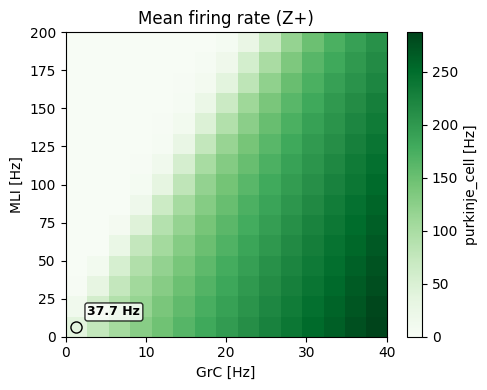

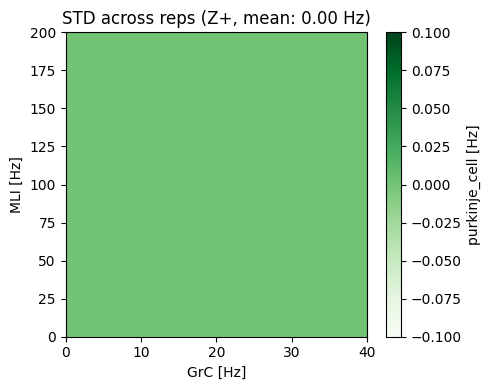

In [108]:
SAVE = True

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]

# Mean TF
fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate (Z+)")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")

# Annotate point (0, 0)
f0 = tf_mean[0, 0]
dx = (extent[1] - extent[0]) / tf_mean.shape[0]  # pixel size (extent = edges, not centers)
dy = (extent[3] - extent[2]) / tf_mean.shape[1]
x0, y0 = extent[0] + dx / 2, extent[2] + dy / 2  # center of pixel (0, 0)
ax1.plot(x0, y0, "o", mfc="none", mec="k", ms=8)
ax1.annotate(f"{f0:.1f} Hz", (x0, y0), xytext=(8, 8), textcoords="offset points",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
fig1.tight_layout()

# STD TF
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax2.set_title(f"STD across reps (Z+, mean: {tf_std.mean():.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
    os.makedirs('output_figs', exist_ok=True)
    fig1.savefig(f"./output_figs/TF_{cell_name}Z+.png", dpi=150)
    fig2.savefig(f"./output_figs/TF_std_{cell_name}Z+.png", dpi=150)

plt.show()

# 2. Change the PC parameters to Zebrin− ones and observe the differences in the single-cell model


purkinje_cell Z+: 37.80 ± 0.04 Hz
purkinje_cell Z-: 84.98 ± 0.08 Hz


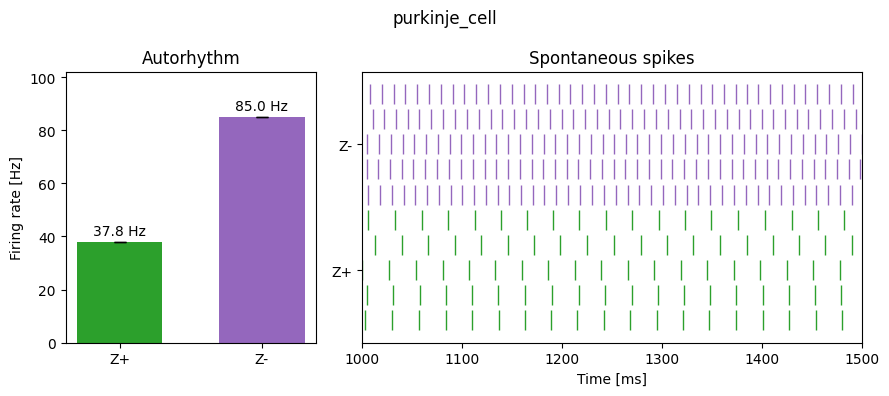

In [101]:
# Z+ from circuit; Z- inherits Z+ and overrides intrinsic params
p_zplus = dict(circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"])
p_zminus = {**p_zplus, "A1": 2434.0008897784705, "A2": 46.12846171566953,
            "I_e": 185.39534745227857, "k_1": 0.2462902995736806,
            "k_2": 0.025023478935133806, "k_adap": 0.20746553238369195}

# Autorhythm: all input rates = 0 (only I_e drives the cell)
zero_rates = {tag: 0.0 for tag in connections}
res, spikes = {}, {}
for lbl, p in [("Z+", p_zplus), ("Z-", p_zminus)]:
    res[lbl] = compute_tf_point(p, zero_rates, n_reps=5)
    # kernel still holds the last simulation: grab spike times per rep
    spikes[lbl] = [sr.get("events")["times"] for sr in nest.GetNodes({"model": "spike_recorder"})]
    print(f"{cell_name} {lbl}: {res[lbl][0]:.2f} ± {res[lbl][1]:.2f} Hz")

colors = {"Z+": "tab:green", "Z-": "tab:purple"}
fig, (ax_bar, ax_ras) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 2]})

bars = ax_bar.bar(res.keys(), [m for m, _ in res.values()], yerr=[s for _, s in res.values()],
                  capsize=4, width=0.6, color=list(colors.values()))
ax_bar.bar_label(bars, fmt="%.1f Hz", padding=3)
ax_bar.set_ylabel("Firing rate [Hz]")
ax_bar.set_title("Autorhythm")
ax_bar.margins(y=0.2)

# Raster: 500 ms after transient, one row per rep
t_win = (1000.0, 1500.0)
row = 0
for lbl, reps in spikes.items():
    for t in reps:
        t = t[(t >= t_win[0]) & (t < t_win[1])]
        ax_ras.vlines(t, row + 0.6, row + 1.4, color=colors[lbl], lw=1)
        row += 1
ax_ras.set_yticks([2.5 + 5 * k + 0.5 for k in range(2)] if False else
                  [len(spikes["Z+"]) / 2 + 0.5, len(spikes["Z+"]) + len(spikes["Z-"]) / 2 + 0.5],
                  list(spikes.keys()))
ax_ras.set_xlim(*t_win)
ax_ras.set_xlabel("Time [ms]")
ax_ras.set_title("Spontaneous spikes")

fig.suptitle(cell_name)
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/autorhythm_{cell_name}.png", dpi=150)
plt.show()

In [102]:
cell_params_zplus = circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"]

cell_params_zminus = {
    **cell_params_zplus,
    "A1": 2434.0008897784705,
    "A2": 46.12846171566953,
    "I_e": 185.39534745227857,
    "k_1": 0.2462902995736806,
    "k_2": 0.025023478935133806,
    "k_adap": 0.20746553238369195,
}

In [103]:
tf_mean1 = np.zeros(shape)
tf_std1 = np.zeros(shape)

In [104]:
for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name} Z-"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(cell_params_zminus, rates_dict)
    tf_mean1[idx] = mean
    tf_std1[idx] = std

Computing transfer function for purkinje_cell Z-:   0%|          | 0/225 [00:00<?, ?it/s]

In [105]:
# Save TF
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}_Z-.npz', tf_mean=tf_mean, tf_std=tf_std,
            tags = unique_labels, **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)},
        )

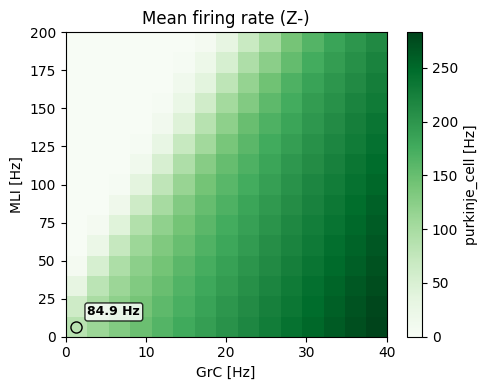

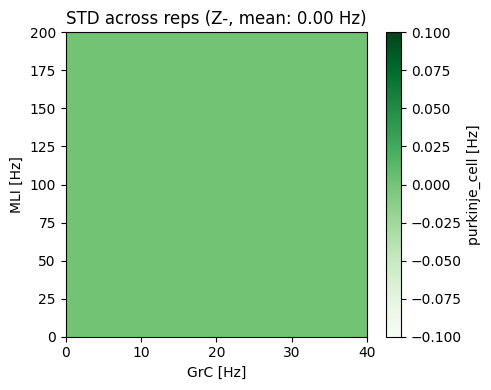

In [107]:
SAVE = True

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]

# Mean TF
fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate (Z-)")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")

# Annotate point (0, 0)
f0 = tf_mean1[0, 0]
dx = (extent[1] - extent[0]) / tf_mean1.shape[0]  # pixel size (extent = edges, not centers)
dy = (extent[3] - extent[2]) / tf_mean1.shape[1]
x0, y0 = extent[0] + dx / 2, extent[2] + dy / 2   # center of pixel (0, 0)
ax1.plot(x0, y0, "o", mfc="none", mec="k", ms=8)
ax1.annotate(f"{f0:.1f} Hz", (x0, y0), xytext=(8, 8), textcoords="offset points",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
fig1.tight_layout()

# STD TF
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax2.set_title(f"STD across reps (Z-, mean: {tf_std1.mean():.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
    os.makedirs('output_figs', exist_ok=True)
    fig1.savefig(f"./output_figs/TF_{cell_name}Z-.png", dpi=150)
    fig2.savefig(f"./output_figs/TF_std_{cell_name}Z-.png", dpi=150)

plt.show()

In [109]:
diff_tf = np.diff(tf_mean1-tf_mean)

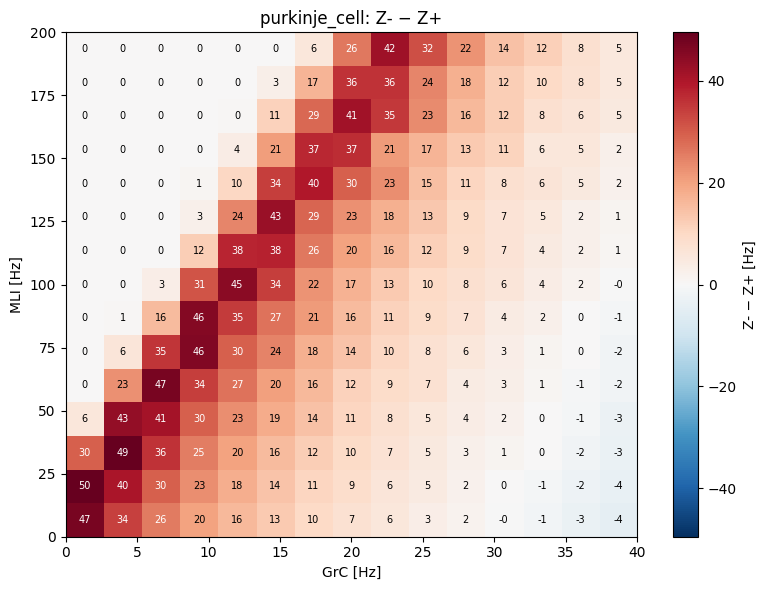

In [112]:
diff_tf = tf_mean1 - tf_mean   # Z- minus Z+ [Hz]

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]
dx = (extent[1] - extent[0]) / diff_tf.shape[0]
dy = (extent[3] - extent[2]) / diff_tf.shape[1]

m = np.nanmax(np.abs(diff_tf))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(diff_tf.T, origin='lower', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-m, vmax=m)
fig.colorbar(im, ax=ax, label="Z- − Z+ [Hz]")

for i in range(diff_tf.shape[0]):
    for j in range(diff_tf.shape[1]):
        val = diff_tf[i, j]
        ax.text(extent[0] + (i + 0.5) * dx, extent[2] + (j + 0.5) * dy, f"{val:.0f}",
                ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.5 * m else 'black')

ax.set_xlabel(f"{unique_labels[0]} [Hz]")
ax.set_ylabel(f"{unique_labels[1]} [Hz]")
ax.set_title(f"{cell_name}: Z- − Z+")
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/TF_diff_{cell_name}.png", dpi=150)
plt.show()

# 3. Introduce electrophysiological alterations: SCA6-like condition

The PC multicompartmental model was modified to reproduce **SCA6-like electrophysiological dysfunction**, focusing on alterations of the CaV2.1 (P/Q-type calcium) channel.

The corresponding EGLIF model was then re-tuned to capture the altered electrophysiological response of the SCA6-like PC.

We will now generate the corresponding numerical TF template and compare it with the templates obtained for Zebrin+ and Zebrin− PCs.

Identify and discuss how the SCA6-like alterations affect the overall shape and dynamical properties of the TF.


In [119]:
p_sca6 = {**p_zplus,
         "A1": 1019.1073863509907, "A2": 17.069638354327974,
         "I_e": 106.20301507711635, "k_1": 0.1702243516348732,
         "k_2": 0.043846843811860374, "k_adap": 0.4754666902516146}

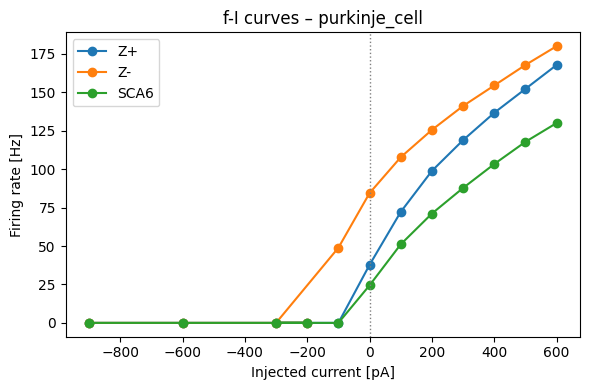

In [121]:
cells = {"Z+": p_zplus, "Z-": p_zminus, "SCA6": p_sca6}

# Current steps from results_tofitEglif/PC filenames [pA]
currents = np.array([-900., -600., -200., -300, -100., 0, 100, 200, 300, 400, 500, 600])

t_pre, t_step, t_skip = 1000.0, 1000.0, 100.0   # baseline, step duration, transient skipped [ms]

def fi_curve(params, currents, seed=1234):
    """Steady-state f-I: one neuron per current, step on top of I_e via dc_generator."""
    nest.ResetKernel()
    nest.set_verbosity("M_WARNING")
    nest.set(resolution=0.1, print_time=False, rng_seed=seed)
    try:
        nest.Install("cerebmodule")
    except Exception:
        pass
    n = len(currents)
    neurons = nest.Create("eglif_cond_alpha_multisyn", n, params=params)
    srs = nest.Create("spike_recorder", n)
    dcs = nest.Create("dc_generator", n, params=[{"amplitude": float(I), "start": t_pre,
                                                   "stop": t_pre + t_step} for I in currents])
    nest.Connect(dcs, neurons, "one_to_one")
    nest.Connect(neurons, srs, "one_to_one")
    nest.Simulate(t_pre + t_step)
    t0, t1 = t_pre + t_skip, t_pre + t_step
    return np.array([np.sum((t >= t0) & (t < t1)) / ((t1 - t0) / 1000.0)
                     for t in (sr.get("events")["times"] for sr in srs)])

fi = {lbl: fi_curve(p, currents) for lbl, p in cells.items()}

fig, ax = plt.subplots(figsize=(6, 4))
for lbl, rates in fi.items():
    ax.plot(currents, rates, "o-", label=lbl)
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("Injected current [pA]")
ax.set_ylabel("Firing rate [Hz]")
ax.set_title(f"f-I curves – {cell_name}")
ax.legend()
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/FI_{cell_name}.png", dpi=150)
plt.show()